# Load registration and login sheets

This notebook loads data from the registration and login Google Sheets into Pandas dataframes.

In [1]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for importing config.py
project_root = Path.cwd().resolve().parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


In [2]:
import pandas as pd
import gspread
from google.oauth2.service_account import Credentials
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config

creds_path = Path(config.CREDENTIALS_FILE)
if not creds_path.is_absolute():
    creds_path = project_root / creds_path

creds = Credentials.from_service_account_file(
    str(creds_path),
    scopes=config.SCOPES,
)
client = gspread.authorize(creds)

# Registration sheet (main user sheet)
registration_sheet = client.open_by_key(config.SHEET_ID).sheet1
registration_values = registration_sheet.get_all_values()
if registration_values:
    registration_headers = registration_values.pop(0)
    registration_df = pd.DataFrame(registration_values, columns=registration_headers)
    registration_df = registration_df.loc[:, registration_df.columns != '']
else:
    registration_df = pd.DataFrame()

# Login sheet
login_sheet = client.open_by_key(config.LOGIN_SHEET_ID).sheet1
login_values = login_sheet.get_all_values()
if login_values:
    login_headers = login_values.pop(0)
    login_df = pd.DataFrame(login_values, columns=login_headers)
    login_df = login_df.loc[:, login_df.columns != '']
else:
    login_df = pd.DataFrame()

registration_df.head(), login_df.head()


(            Timestamp  \
 0  1/21/2025 10:49:29   
 1  2/14/2025 13:23:32   
 2  1/24/2025 12:54:36   
 3   5/2/2025 13:09:37   
 4   4/4/2025 12:41:37   
 
   I agree to St Dunstan's Food Bank using my data for the purposes described above.  \
 0                                Click here to agree                                  
 1                                Click here to agree                                  
 2                                Click here to agree                                  
 3                                Click here to agree                                  
 4                                Click here to agree                                  
 
   First Name   Surname Mobile Number Email Postcode  \
 0       Azad       Ali                       E1 0AX   
 1      Ausra  Akuliene   07429533360        E14 9TJ   
 2      Ambia     Akter   07869255582        E14 7RD   
 3       Azob       Ali   07508014550        E14 7AX   
 4      Ahmed       Ali    07448

In [3]:
import pandas as pd

login_df = login_df.copy()

# 1) Clean the Timestamp strings (strip tabs/spaces/newlines)
ts = login_df["Timestamp"].astype(str).str.strip()

# 2) Parse ISO first (YYYY-MM-DD HH:MM:SS)
parsed = pd.to_datetime(ts, format="%Y-%m-%d %H:%M:%S", errors="coerce")

# 3) Parse US format for the remaining (M/D/YYYY HH:MM:SS)
parsed = parsed.fillna(pd.to_datetime(ts, format="%m/%d/%Y %H:%M:%S", errors="coerce"))

# 4) Assign back
login_df["Timestamp_Parsed"] = parsed

# Optional: see what still failed
bad = login_df[login_df["Timestamp_Parsed"].isna()][["Timestamp"]].head(20)
print(f"Failed to parse: {login_df['Timestamp_Parsed'].isna().sum()} rows")
print(bad)

# Only now drop invalid timestamps
login_df = login_df.dropna(subset=["Timestamp_Parsed"])

Failed to parse: 0 rows
Empty DataFrame
Columns: [Timestamp]
Index: []


In [4]:
login_df

,Timestamp,Username,Day,Timestamp_Parsed
0,1/21/2025 10:46:31,TM3554,Tuesday,2025-01-21 10:46:31
1,1/21/2025 11:11:12,MK2386,Tuesday,2025-01-21 11:11:12
2,1/21/2025 11:54:57,AG6399,Tuesday,2025-01-21 11:54:57
3,1/24/2025 11:18:15,RP2124,Friday,2025-01-24 11:18:15
4,1/24/2025 11:34:13,BM7396,Friday,2025-01-24 11:34:13
...,...,...,...,...
6300,2026-01-23 13:56:52,RB9674,Friday,2026-01-23 13:56:52
6301,2026-01-23 13:58:05,HB5278,Friday,2026-01-23 13:58:05
6302,2026-01-23 13:59:22,SB7665,Friday,2026-01-23 13:59:22
6303,2026-01-23 13:59:53,TD3858,Friday,2026-01-23 13:59:53


In [6]:

# Month as YYYY-MM (keeps sorting correct)
login_df["Month"] = login_df["Timestamp_Parsed"].dt.to_period("M").astype(str)

# ---- 2) Bring relationship status onto each login (join via Username) ----
registration_df = registration_df.copy()

# Ensure Username exists in both
# registration_df.columns should contain: "Username", "Your relationship status"
# login_df.columns should contain: "Username"
login_enriched = login_df.merge(
    registration_df[["Username", "Your relationship status"]],
    on="Username",
    how="left",
)

# If some logins have no matching registration row
login_enriched["Your relationship status"] = login_enriched["Your relationship status"].fillna("Unknown")

# ---- 3) Count logins by Month x Relationship Status ----
counts = (
    login_enriched
    .groupby(["Month", "Your relationship status"])
    .size()
    .reset_index(name="Login Count")
)


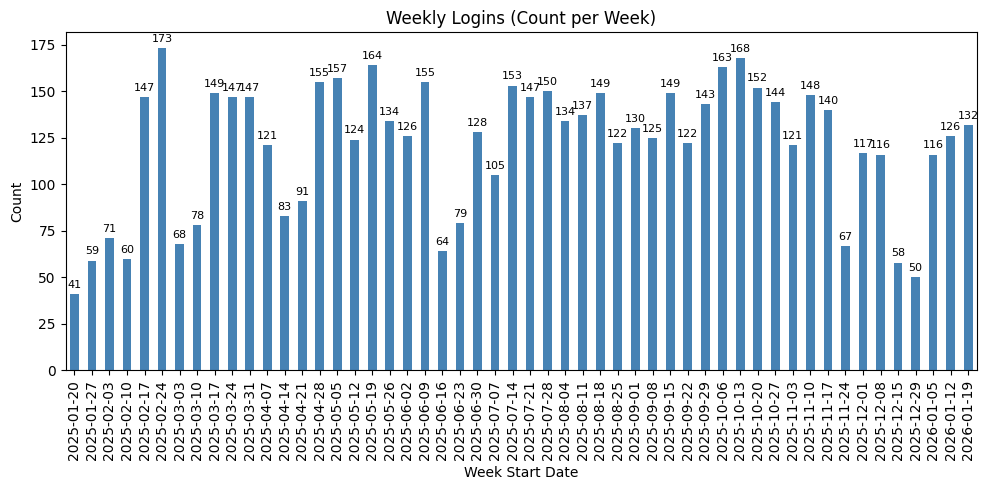

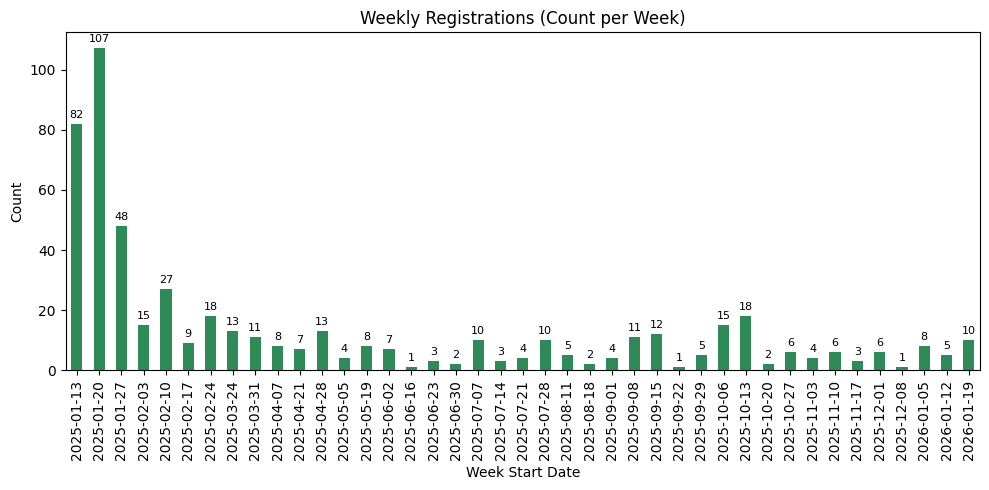

In [ ]:
import matplotlib.pyplot as plt

def parse_timestamp_column(df, column):
    if column not in df.columns:
        return df.assign(Parsed=pd.NaT)
    parsed = pd.to_datetime(df[column], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    parsed = parsed.fillna(pd.to_datetime(df[column], format='%m/%d/%Y %H:%M:%S', errors='coerce'))
    return df.assign(Parsed=parsed)

def add_bar_labels(ax):
    for bar in ax.patches:
        height = bar.get_height()
        if height:
            ax.annotate(
                f'{int(height)}',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=90,          # ✅ vertical text
                xytext=(0, 3),
                textcoords='offset points',
            )


def weekly_counts(df, title, color):
    if df.empty:
        print(f'No data available for {title.lower()}.')
        return

    df = df.copy()
    df['Week'] = df['Parsed'].dt.to_period('W').apply(lambda p: p.start_time)

    weekly = df.groupby('Week').size()

    fig, ax = plt.subplots(figsize=(10, 5))
    weekly.plot(kind='bar', color=color, ax=ax)

    # ✅ Replace timestamp tick labels with date-only labels
    ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in weekly.index], rotation=90)

    ax.set_title(title)
    ax.set_xlabel('Week Start Date')
    ax.set_ylabel('Count')
    add_bar_labels(ax)
    fig.tight_layout()
    plt.show()


# Weekly login counts
logins_parsed = parse_timestamp_column(login_df.copy(), 'Timestamp').dropna(subset=['Parsed'])
weekly_counts(logins_parsed, 'Weekly Logins (Count per Week)', 'steelblue')

# Weekly registration counts
registrations_parsed = parse_timestamp_column(registration_df.copy(), 'Timestamp').dropna(subset=['Parsed'])
weekly_counts(registrations_parsed, 'Weekly Registrations (Count per Week)', 'seagreen')


In [39]:
import pandas as pd
import plotly.express as px

# ---- 1) Parse login timestamps robustly ----
df = login_df.copy()

ts = df["Timestamp"].astype(str).str.strip()
parsed = pd.to_datetime(ts, format="%Y-%m-%d %H:%M:%S", errors="coerce")
parsed = parsed.fillna(pd.to_datetime(ts, format="%m/%d/%Y %H:%M:%S", errors="coerce"))

df["Timestamp_Parsed"] = parsed
df = df.dropna(subset=["Timestamp_Parsed"])

# ---- 2) Aggregate logins per month ----
df["Month"] = df["Timestamp_Parsed"].dt.to_period("M").astype(str)

counts = df.groupby("Month").size().reset_index(name="Login Count")

# sort months chronologically
counts["Month_dt"] = pd.to_datetime(counts["Month"] + "-01")
counts = counts.sort_values("Month_dt").drop(columns=["Month_dt"])

month_order = counts["Month"].tolist()

# ---- 3) Plot ----
fig = px.bar(
    counts,
    x="Month",
    y="Login Count",
    title="Login Counts per Month",
    labels={"Month": "Month", "Login Count": "Number of Logins"},
    text="Login Count",
    category_orders={"Month": month_order},
)

fig.update_traces(textposition="outside", texttemplate="%{text}", cliponaxis=False)

fig.update_layout(
    xaxis=dict(
        type="category",
        tickmode="array",
        tickvals=month_order,   # show all months
        ticktext=month_order,
        tickangle=-35,
    ),
    margin=dict(t=70),
)

fig.show()


In [37]:
# Ensure Month stays in chronological order and is treated as a category
month_order = counts["Month"].drop_duplicates().tolist()

fig = px.bar(
    counts,
    x="Month",
    y="Login Count",
    color="Your relationship status",
    barmode="group",
    title="Logins per Month by Relationship Status",
    labels={"Month": "Month", "Login Count": "Number of Logins", "Your relationship status": "Relationship Status"},
    text="Login Count",
    category_orders={"Month": month_order},  # keeps order
)

fig.update_traces(textposition="outside", texttemplate="%{text}", cliponaxis=False)

fig.update_layout(
    xaxis=dict(
        type="category",
        tickmode="array",
        tickvals=month_order,   # force every month tick
        ticktext=month_order,
        tickangle=-35,
    ),
    uniformtext_minsize=10,
    uniformtext_mode="hide",
    margin=dict(t=70),
)

fig.show()


In [19]:
import pandas as pd
import plotly.express as px

def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    dt = dt.fillna(pd.to_datetime(s, format="%m/%d/%Y %H:%M:%S", errors="coerce"))
    return dt

# -----------------------
# CONFIG
# -----------------------
ID_COL = "Username"
LOGIN_TS_COL = "Timestamp"
PROPERTY_COL = "Property Type"   # <- make sure this matches registration_df.columns

# -----------------------
# 1) Prepare + parse logins
# -----------------------
log = login_df.copy()
log["Timestamp_Parsed"] = parse_mixed_timestamp(log[LOGIN_TS_COL])
log = log.dropna(subset=["Timestamp_Parsed"])

log["Month"] = log["Timestamp_Parsed"].dt.to_period("M").astype(str)

# -----------------------
# 2) Join Property Type from registration onto logins
# -----------------------
reg = registration_df.copy()

reg_lookup = (
    reg[[ID_COL, PROPERTY_COL]]
    .dropna(subset=[ID_COL])
    .drop_duplicates(subset=[ID_COL], keep="last")
)

log = log.merge(reg_lookup, on=ID_COL, how="left")
log[PROPERTY_COL] = log[PROPERTY_COL].fillna("Unknown")

# -----------------------
# 3) Count logins per month by property type
# -----------------------
counts = (
    log.groupby(["Month", PROPERTY_COL])
       .size()
       .reset_index(name="Login Count")
)

# sort months chronologically + show all months
counts["Month_dt"] = pd.to_datetime(counts["Month"] + "-01")
counts = counts.sort_values("Month_dt").drop(columns=["Month_dt"])

month_order = counts["Month"].drop_duplicates().tolist()
property_order = sorted(log[PROPERTY_COL].dropna().unique().tolist())

# optional: include 0s for missing month/property combos
full_index = pd.MultiIndex.from_product([month_order, property_order], names=["Month", PROPERTY_COL])
counts = (
    counts.set_index(["Month", PROPERTY_COL])
          .reindex(full_index, fill_value=0)
          .reset_index()
)

# -----------------------
# 4) Plot
# -----------------------
fig = px.bar(
    counts,
    x="Month",
    y="Login Count",
    color=PROPERTY_COL,
    barmode="group",
    text="Login Count",
    title="Logins per Month by Property Type",
    labels={"Month": "Month", "Login Count": "Number of Logins", PROPERTY_COL: "Property Type"},
    category_orders={"Month": month_order, PROPERTY_COL: property_order},
)

fig.update_traces(textposition="outside", texttemplate="%{text}", cliponaxis=False)

fig.update_layout(
    xaxis=dict(
        type="category",
        tickmode="array",
        tickvals=month_order,
        ticktext=month_order,
        tickangle=-35,
    ),
    uniformtext_minsize=10,
    uniformtext_mode="show",
    margin=dict(t=80),
)

fig.show()


In [20]:
import pandas as pd
import plotly.express as px

def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    dt = dt.fillna(pd.to_datetime(s, format="%m/%d/%Y %H:%M:%S", errors="coerce"))
    return dt

# -----------------------
# CONFIG
# -----------------------
ID_COL = "Username"
LOGIN_TS_COL = "Timestamp"
WORK_COL = "Right to work in the UK for yourself"  # exact column name in registration_df

# -----------------------
# 1) Parse logins + month
# -----------------------
log = login_df.copy()
log["Timestamp_Parsed"] = parse_mixed_timestamp(log[LOGIN_TS_COL])
log = log.dropna(subset=["Timestamp_Parsed"])
log["Month"] = log["Timestamp_Parsed"].dt.to_period("M").astype(str)

# -----------------------
# 2) Join work-status from registration onto each login
# -----------------------
reg = registration_df.copy()
reg_lookup = (
    reg[[ID_COL, WORK_COL]]
    .dropna(subset=[ID_COL])
    .drop_duplicates(subset=[ID_COL], keep="last")
)

log = log.merge(reg_lookup, on=ID_COL, how="left")
log[WORK_COL] = log[WORK_COL].fillna("Unknown")

# -----------------------
# 3) Count logins per month by work-status
# -----------------------
counts = (
    log.groupby(["Month", WORK_COL])
       .size()
       .reset_index(name="Login Count")
)

# sort months chronologically + show all months
counts["Month_dt"] = pd.to_datetime(counts["Month"] + "-01")
counts = counts.sort_values("Month_dt").drop(columns=["Month_dt"])

month_order = counts["Month"].drop_duplicates().tolist()
work_order = sorted(log[WORK_COL].dropna().unique().tolist())

# optional: include 0s for missing month/status combos
full_index = pd.MultiIndex.from_product([month_order, work_order], names=["Month", WORK_COL])
counts = (
    counts.set_index(["Month", WORK_COL])
          .reindex(full_index, fill_value=0)
          .reset_index()
)

# show labels only for non-zero counts (prevents clutter)
counts["Label"] = counts["Login Count"].where(counts["Login Count"] > 0, "")

# -----------------------
# 4) Plot
# -----------------------
fig = px.bar(
    counts,
    x="Month",
    y="Login Count",
    color=WORK_COL,
    barmode="group",
    text="Label",
    title="Logins per Month by Right to Work Status",
    labels={"Month": "Month", "Login Count": "Number of Logins", WORK_COL: "Right to Work Status"},
    category_orders={"Month": month_order, WORK_COL: work_order},
)

fig.update_traces(textposition="auto", cliponaxis=False)

fig.update_layout(
    xaxis=dict(
        type="category",
        tickmode="array",
        tickvals=month_order,
        ticktext=month_order,
        tickangle=-35,
    ),
    uniformtext_minsize=9,
    margin=dict(t=80),
)

fig.show()


In [ ]:
# Ensure Month stays in chronological order and is treated as a category
month_order = counts["Month"].drop_duplicates().tolist()

fig = px.bar(
    counts,
    x="Month",
    y="Login Count",
    color="Your relationship status",
    barmode="group",
    title="Logins per Month by Relationship Status",
    labels={"Month": "Month", "Login Count": "Number of Logins", "Your relationship status": "Relationship Status"},
    text="Login Count",
    category_orders={"Month": month_order},  # keeps order
)

fig.update_traces(textposition="outside", texttemplate="%{text}", cliponaxis=False)

fig.update_layout(
    xaxis=dict(
        type="category",
        tickmode="array",
        tickvals=month_order,   # force every month tick
        ticktext=month_order,
        tickangle=-35,
    ),
    uniformtext_minsize=10,
    uniformtext_mode="hide",
    margin=dict(t=70),
)

fig.show()


In [49]:
import pandas as pd
import plotly.express as px

def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    dt = dt.fillna(pd.to_datetime(s, format="%m/%d/%Y %H:%M:%S", errors="coerce"))
    return dt

# -----------------------
# CONFIG: set registration timestamp column name
# -----------------------
REG_TS_COL = "Timestamp"  # change if your registration sheet uses a different header

reg = registration_df.copy()
reg["Timestamp_Parsed"] = parse_mixed_timestamp(reg[REG_TS_COL])
reg = reg.dropna(subset=["Timestamp_Parsed"])

# month label like 2025-01
reg["Month"] = reg["Timestamp_Parsed"].dt.to_period("M").astype(str)

# relationship status (already in registration_df)
REL_COL = "Your relationship status"
reg[REL_COL] = reg[REL_COL].fillna("Unknown")

# -----------------------
# Aggregate: registrations per month by relationship status
# -----------------------
counts = (
    reg.groupby(["Month", REL_COL])
       .size()
       .reset_index(name="Registration Count")
)

# sort months chronologically + keep all months on axis
counts["Month_dt"] = pd.to_datetime(counts["Month"] + "-01")
counts = counts.sort_values("Month_dt").drop(columns=["Month_dt"])

month_order = counts["Month"].drop_duplicates().tolist()
status_order = sorted(reg[REL_COL].dropna().unique().tolist())

# optional: include 0s for missing combinations
full_index = pd.MultiIndex.from_product([month_order, status_order], names=["Month", REL_COL])
counts = (
    counts.set_index(["Month", REL_COL])
          .reindex(full_index, fill_value=0)
          .reset_index()
)

# -----------------------
# Plot: grouped bars + counts above bars
# -----------------------
fig = px.bar(
    counts,
    x="Month",
    y="Registration Count",
    color=REL_COL,
    barmode="group",
    text="Registration Count",
    title="Registrations per Month by Relationship Status",
    labels={"Month": "Month", "Registration Count": "Number of Registrations", REL_COL: "Relationship Status"},
    category_orders={"Month": month_order, REL_COL: status_order},
)

fig.update_traces(textposition="outside", texttemplate="%{text}", cliponaxis=False)

fig.update_layout(
    xaxis=dict(
        type="category",
        tickmode="array",
        tickvals=month_order,
        ticktext=month_order,
        tickangle=-35,
    ),
    uniformtext_minsize=10,
    uniformtext_mode="hide",
    margin=dict(t=80),
)

fig.show()


In [40]:
import pandas as pd
import plotly.express as px

# ---------------------------
# 0) Robust timestamp parsing
# ---------------------------
def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    dt = dt.fillna(pd.to_datetime(s, format="%m/%d/%Y %H:%M:%S", errors="coerce"))
    return dt

# ---------------------------------------
# 1) Build "last Sunday + next 7 days" windows
# ---------------------------------------
def build_last_week_windows(min_ts: pd.Timestamp, max_ts: pd.Timestamp) -> pd.DataFrame:
    if pd.isna(min_ts) or pd.isna(max_ts):
        return pd.DataFrame(columns=["Month", "Start", "End"])

    months = pd.period_range(min_ts.to_period("M"), max_ts.to_period("M"), freq="M")

    rows = []
    for p in months:
        first = pd.Timestamp(p.year, p.month, 1)
        last_day = first + pd.offsets.MonthEnd(0)            # last calendar day of month (00:00)
        # weekday: Mon=0 ... Sun=6. We want last Sunday <= last_day
        delta_days = (last_day.weekday() - 6) % 7
        last_sunday = (last_day - pd.Timedelta(days=delta_days)).normalize()
        start = last_sunday
        end = start + pd.Timedelta(days=7)                  # [start, end)
        rows.append({
            "Month": f"{p.year:04d}-{p.month:02d}",
            "Start": start,
            "End": end
        })

    return pd.DataFrame(rows)

# ---------------------------------------
# 2) Prepare + enrich login data with relationship status
# ---------------------------------------
login = login_df.copy()
reg = registration_df.copy()

login["Timestamp_Parsed"] = parse_mixed_timestamp(login["Timestamp"])
login = login.dropna(subset=["Timestamp_Parsed"])

# Join relationship status onto each login via Username
login = login.merge(
    reg[["Username", "Your relationship status"]],
    on="Username",
    how="left"
)
login["Your relationship status"] = login["Your relationship status"].fillna("Unknown")

# ---------------------------------------
# 3) Assign each login to its month’s "last-week window"
# ---------------------------------------
windows = build_last_week_windows(login["Timestamp_Parsed"].min(), login["Timestamp_Parsed"].max())

intervals = pd.IntervalIndex.from_arrays(windows["Start"], windows["End"], closed="left")
idx = intervals.get_indexer(login["Timestamp_Parsed"])

# keep only logins that fall inside any last-week window
login_last_week = login[idx != -1].copy()
login_last_week["Month"] = windows.loc[idx[idx != -1], "Month"].values  # Month label of the window

# ---------------------------------------
# 4) Aggregate counts Month x Relationship Status
# ---------------------------------------
counts = (
    login_last_week
    .groupby(["Month", "Your relationship status"])
    .size()
    .reset_index(name="Login Count")
)

# OPTIONAL: ensure months with zero show up (nice for consistent x-axis)
month_order = windows["Month"].tolist()
status_order = sorted(login["Your relationship status"].dropna().unique().tolist())

full_index = pd.MultiIndex.from_product([month_order, status_order], names=["Month", "Your relationship status"])
counts = (
    counts.set_index(["Month", "Your relationship status"])
          .reindex(full_index, fill_value=0)
          .reset_index()
)

# ---------------------------------------
# 5) Plot (grouped bars + labels + show all months)
# ---------------------------------------
fig = px.bar(
    counts,
    x="Month",
    y="Login Count",
    color="Your relationship status",
    barmode="group",
    text="Login Count",
    title="Logins in the Last Week of Each Month (Last Sunday → Next 7 Days)",
    labels={
        "Month": "Month (window anchored at last Sunday)",
        "Login Count": "Number of Logins",
        "Your relationship status": "Relationship Status",
    },
    category_orders={"Month": month_order, "Your relationship status": status_order},
)

fig.update_traces(textposition="outside", texttemplate="%{text}", cliponaxis=False)
fig.update_layout(
    xaxis=dict(
        type="category",
        tickmode="array",
        tickvals=month_order,
        ticktext=month_order,
        tickangle=-35,
    ),
    uniformtext_minsize=10,
    uniformtext_mode="hide",
    margin=dict(t=80),
)

fig.show()


In [48]:
import pandas as pd
import plotly.express as px

# ---------------------------
# 0) Robust timestamp parsing
# ---------------------------
def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    dt = dt.fillna(pd.to_datetime(s, format="%m/%d/%Y %H:%M:%S", errors="coerce"))
    return dt

# ---------------------------------------
# 1) Build "last Sunday + next 7 days" windows
# ---------------------------------------
def build_last_week_windows(min_ts: pd.Timestamp, max_ts: pd.Timestamp) -> pd.DataFrame:
    if pd.isna(min_ts) or pd.isna(max_ts):
        return pd.DataFrame(columns=["Month", "Start", "End"])

    months = pd.period_range(min_ts.to_period("M"), max_ts.to_period("M"), freq="M")

    rows = []
    for p in months:
        first = pd.Timestamp(p.year, p.month, 1)
        last_day = first + pd.offsets.MonthEnd(0)
        delta_days = (last_day.weekday() - 6) % 7  # last Sunday (weekday=6)
        last_sunday = (last_day - pd.Timedelta(days=delta_days)).normalize()
        start = last_sunday
        end = start + pd.Timedelta(days=7)         # [start, end)
        rows.append({"Month": f"{p.year:04d}-{p.month:02d}", "Start": start, "End": end})

    return pd.DataFrame(rows)

# ---------------------------------------
# 2) Prepare registration data
# ---------------------------------------
reg = registration_df.copy()

# If your registration timestamp column is NOT "Timestamp", change it here
REG_TS_COL = "Timestamp"  # common for Google Form exports

reg["Timestamp_Parsed"] = parse_mixed_timestamp(reg[REG_TS_COL])
reg = reg.dropna(subset=["Timestamp_Parsed"])

# Relationship status lives in registration_df already
reg["Your relationship status"] = reg["Your relationship status"].fillna("Unknown")

# ---------------------------------------
# 3) Assign each registration to its month’s "last-week window"
# ---------------------------------------
windows = build_last_week_windows(reg["Timestamp_Parsed"].min(), reg["Timestamp_Parsed"].max())

intervals = pd.IntervalIndex.from_arrays(windows["Start"], windows["End"], closed="left")
idx = intervals.get_indexer(reg["Timestamp_Parsed"])

reg_last_week = reg[idx != -1].copy()
reg_last_week["Month"] = windows.loc[idx[idx != -1], "Month"].values

# ---------------------------------------
# 4) Aggregate counts Month x Relationship Status (REGISTRATIONS)
# ---------------------------------------
counts = (
    reg_last_week
    .groupby(["Month", "Your relationship status"])
    .size()
    .reset_index(name="Registration Count")
)

# Ensure all months/statuses appear (fill missing with 0)
month_order = windows["Month"].tolist()
status_order = sorted(reg["Your relationship status"].dropna().unique().tolist())

full_index = pd.MultiIndex.from_product([month_order, status_order], names=["Month", "Your relationship status"])
counts = (
    counts.set_index(["Month", "Your relationship status"])
          .reindex(full_index, fill_value=0)
          .reset_index()
)

# ---------------------------------------
# 5) Plot
# ---------------------------------------
fig = px.bar(
    counts,
    x="Month",
    y="Registration Count",
    color="Your relationship status",
    barmode="group",
    text="Registration Count",
    title="Registrations in the Last Week of Each Month (Last Sunday → Next 7 Days)",
    labels={
        "Month": "Month (window anchored at last Sunday)",
        "Registration Count": "Number of Registrations",
        "Your relationship status": "Relationship Status",
    },
    category_orders={"Month": month_order, "Your relationship status": status_order},
)

fig.update_traces(textposition="outside", texttemplate="%{text}", cliponaxis=False)
fig.update_layout(
    xaxis=dict(
        type="category",
        tickmode="array",
        tickvals=month_order,
        ticktext=month_order,
        tickangle=-35,
    ),
    uniformtext_minsize=10,
    uniformtext_mode="hide",
    margin=dict(t=80),
)

fig.show()


In [41]:
import pandas as pd

def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    dt = dt.fillna(pd.to_datetime(s, format="%m/%d/%Y %H:%M:%S", errors="coerce"))
    return dt

# ---- 1) Parse timestamps ----
df = login_df.copy()
df["Timestamp_Parsed"] = parse_mixed_timestamp(df["Timestamp"])
df = df.dropna(subset=["Timestamp_Parsed"])

# ---- 2) Filter to year 2025 (calendar year) ----
start = pd.Timestamp("2025-01-01")
end = pd.Timestamp("2026-01-01")  # exclusive
df_2025 = df[(df["Timestamp_Parsed"] >= start) & (df["Timestamp_Parsed"] < end)]

# ---- 3) Pick the ID column ----
# Change this if your ID column is named differently.
ID_COL = "Username"   # e.g. "ID", "User ID", "Email", etc.

# ---- 4) Leaderboard: top 10 by login count ----
leaderboard = (
    df_2025.groupby(ID_COL)
          .size()
          .reset_index(name="Visit Count")
          .sort_values("Visit Count", ascending=False)
          .head(10)
          .reset_index(drop=True)
)

print(leaderboard)


  Username  Visit Count
0    NJ174           58
1   AK3246           57
2   SB5632           50
3   SB7124           43
4   KI1224           42
5   RB1321           42
6   MB8093           40
7   AF1519           40
8   RA5984           39
9   SB1095           39


In [46]:
import pandas as pd

def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    dt = dt.fillna(pd.to_datetime(s, format="%m/%d/%Y %H:%M:%S", errors="coerce"))
    return dt

# -----------------------
# CONFIG: set your key columns
# -----------------------
ID_COL = "Username"  # the ID used in BOTH login_df and registration_df to join
NAME_COL = "First Name"    # change to whatever the registration sheet uses (e.g., "Full Name")
SURNAME_COL = "Surname"
REL_COL = "Your relationship status"

# -----------------------
# 1) Parse + filter logins to year 2025
# -----------------------
log = login_df.copy()
log["Timestamp_Parsed"] = parse_mixed_timestamp(log["Timestamp"])
log = log.dropna(subset=["Timestamp_Parsed"])

start = pd.Timestamp("2025-01-01")
end   = pd.Timestamp("2026-01-01")  # exclusive
log_2025 = log[(log["Timestamp_Parsed"] >= start) & (log["Timestamp_Parsed"] < end)]

# -----------------------
# 2) Leaderboard: top 10 by visit count
# -----------------------
leaderboard = (
    log_2025.groupby(ID_COL)
            .size()
            .reset_index(name="Visit Count")
            .sort_values("Visit Count", ascending=False)
            .head(15)
            .reset_index(drop=True)
)

# -----------------------
# 3) Bring name + relationship status from registration_df
#    (dedupe registration rows by ID to avoid exploding joins)
# -----------------------
reg = registration_df.copy()

# keep last non-null per ID (or first; choose what's correct for your data)
reg_subset = (
    reg[[ID_COL, NAME_COL, SURNAME_COL, REL_COL]]
    .dropna(subset=[ID_COL])
    .drop_duplicates(subset=[ID_COL], keep="last")
)

leaderboard = leaderboard.merge(reg_subset, on=ID_COL, how="left")

# fill missing info (if some IDs exist in logins but not in registration)
leaderboard[NAME_COL] = leaderboard[NAME_COL].fillna("Unknown")
leaderboard[SURNAME_COL] = leaderboard[SURNAME_COL].fillna("Unknown")
leaderboard[REL_COL] = leaderboard[REL_COL].fillna("Unknown")

# add rank
leaderboard.insert(0, "Rank", range(1, len(leaderboard) + 1))

print(leaderboard)


    Rank Username  Visit Count First Name      Surname  \
0      1    NJ174           58    Nurjan         Begum   
1      2   AK3246           57      Ayrun       Khanom   
2      3   SB5632           50      Syeda        Begum   
3      4   SB7124           43     Samera        Begum   
4      5   KI1224           42      Kazi         Islam   
5      6   RB1321           42     Rukiya        Begum   
6      7   MB8093           40    Maksuda  Begum Munni   
7      8   AF1519           40      Avril      Forster   
8      9   RA5984           39       Ripa        Akter   
9     10   SB1095           39      Shifa        Begum   
10    11   SA5028           39    Shahnaz       Akthar   
11    12   SR8861           39   Shahinur       Rahman   
12    13   FR4179           38     Fazlur       Rahman   
13    14   HI2621           38     Hazara        Islam   
14    15   NN3549           38    Newarun        Nessa   

   Your relationship status  
0      Family with Children  
1          

In [47]:
leaderboard["Name"] = (
    leaderboard[NAME_COL].astype(str).str.strip().fillna("") + " " +
    leaderboard[SURNAME_COL].astype(str).str.strip().fillna("")
).str.strip()

# if both were Unknown, keep just "Unknown"
leaderboard.loc[
    (leaderboard[NAME_COL] == "Unknown") & (leaderboard[SURNAME_COL] == "Unknown"),
    "Name"
] = "Unknown"

# 2) Rename relationship column + select final columns
leaderboard_final = (
    leaderboard
    .rename(columns={REL_COL: "Relationship status"})
    [["Rank", ID_COL, "Visit Count", "Name", "Relationship status"]]
)

print(leaderboard_final)

    Rank Username  Visit Count                 Name      Relationship status
0      1    NJ174           58         Nurjan Begum     Family with Children
1      2   AK3246           57         Ayrun Khanom         Couple/Partnered
2      3   SB5632           50          Syeda Begum                   Single
3      4   SB7124           43         Samera Begum     Single Parent Family
4      5   KI1224           42           Kazi Islam         Couple/Partnered
5      6   RB1321           42         Rukiya Begum     Family with Children
6      7   MB8093           40  Maksuda Begum Munni     Single Parent Family
7      8   AF1519           40        Avril Forster     Family with Children
8      9   RA5984           39           Ripa Akter     Family with Children
9     10   SB1095           39          Shifa Begum  Married/Civil partnered
10    11   SA5028           39       Shahnaz Akthar                   Single
11    12   SR8861           39      Shahinur Rahman     Family with Children

In [8]:
import pandas as pd
import plotly.express as px

def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    dt = dt.fillna(pd.to_datetime(s, format="%m/%d/%Y %H:%M:%S", errors="coerce"))
    return dt

# -----------------------
# CONFIG
# -----------------------
ID_COL = "Username"
LOGIN_TS_COL = "Timestamp"
POSTCODE_COL = "Postcode"  # change if different
REL_COL = "Your relationship status"

TARGET_DISTRICT = "E1"     # <-- set this to any district you want (e.g., "E1", "SW1A", "N16")

# -----------------------
# 1) Prepare registration: postcode -> district
# -----------------------
reg = registration_df.copy()

# Extract district = first token before space; normalize (strip/upper)
reg["Postcode_District"] = (
    reg[POSTCODE_COL]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.split()
    .str[0]
)

# keep one row per user for join
reg_lookup = (
    reg[[ID_COL, "Postcode_District", REL_COL]]
    .dropna(subset=[ID_COL])
    .drop_duplicates(subset=[ID_COL], keep="last")
)

# -----------------------
# 2) Prepare logins + enrich with district
# -----------------------
log = login_df.copy()
log["Timestamp_Parsed"] = parse_mixed_timestamp(log[LOGIN_TS_COL])
log = log.dropna(subset=["Timestamp_Parsed"])

log = log.merge(reg_lookup, on=ID_COL, how="left")
log["Postcode_District"] = log["Postcode_District"].fillna("Unknown")
log[REL_COL] = log[REL_COL].fillna("Unknown")

# -----------------------
# 3) Filter to district and aggregate per month
# -----------------------
log_d = log[log["Postcode_District"] == TARGET_DISTRICT].copy()

log_d["Month"] = log_d["Timestamp_Parsed"].dt.to_period("M").astype(str)
counts = log_d.groupby("Month").size().reset_index(name="Login Count")

# sort months and show all ticks
counts["Month_dt"] = pd.to_datetime(counts["Month"] + "-01")
counts = counts.sort_values("Month_dt").drop(columns=["Month_dt"])
month_order = counts["Month"].tolist()

# -----------------------
# 4) Plot (simple monthly counts for that district)
# -----------------------
fig = px.bar(
    counts,
    x="Month",
    y="Login Count",
    text="Login Count",
    title=f"Logins per Month — Postcode District {TARGET_DISTRICT}",
    labels={"Month": "Month", "Login Count": "Number of Logins"},
    category_orders={"Month": month_order},
)

fig.update_traces(textposition="outside", cliponaxis=False)

fig.update_layout(
    xaxis=dict(
        type="category",
        tickmode="array",
        tickvals=month_order,
        ticktext=month_order,
        tickangle=-35,
    ),
    margin=dict(t=80),
)

fig.show()


In [16]:
import pandas as pd
import plotly.express as px

def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    dt = dt.fillna(pd.to_datetime(s, format="%m/%d/%Y %H:%M:%S", errors="coerce"))
    return dt

# -----------------------
# CONFIG
# -----------------------
ID_COL = "Username"
LOGIN_TS_COL = "Timestamp"
POSTCODE_COL = "Postcode"  # change if needed

# optional: filter to year 2025 like before
FILTER_2025 = True

# -----------------------
# 1) Build user -> postcode district lookup from registration_df
# -----------------------
reg = registration_df.copy()

reg["Postcode_District"] = (
    reg[POSTCODE_COL]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.split()
    .str[0]         # part before the space, e.g., "E1" from "E1 0ND"
)

user_district = (
    reg[[ID_COL, "Postcode_District"]]
    .dropna(subset=[ID_COL])
    .drop_duplicates(subset=[ID_COL], keep="last")
)

# -----------------------
# 2) Parse login timestamps and (optionally) filter to 2025
# -----------------------
log = login_df.copy()
log["Timestamp_Parsed"] = parse_mixed_timestamp(log[LOGIN_TS_COL])
log = log.dropna(subset=["Timestamp_Parsed"])

if FILTER_2025:
    start = pd.Timestamp("2025-01-01")
    end = pd.Timestamp("2026-01-01")  # exclusive
    log = log[(log["Timestamp_Parsed"] >= start) & (log["Timestamp_Parsed"] < end)]

# -----------------------
# 3) Join district onto each login, then count logins per district
# -----------------------
log = log.merge(user_district, on=ID_COL, how="left")
log["Postcode_District"] = log["Postcode_District"].fillna("Unknown")

district_counts = (
    log.groupby("Postcode_District")
       .size()
       .reset_index(name="Login Count")
       .sort_values("Login Count", ascending=False)
)

# Optional: keep only top N districts
TOP_N = 5  # e.g., 20
if TOP_N:
    district_counts = district_counts.head(TOP_N)

# -----------------------
# 4) Plot: x=district, y=count
# -----------------------
fig = px.bar(
    district_counts,
    x="Postcode_District",
    y="Login Count",
    text="Login Count",
    title=("Logins by Postcode District (2025)" if FILTER_2025 else "Logins by Postcode District"),
    labels={"Postcode_District": "Postcode District", "Login Count": "Number of Logins"},
)

fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_layout(
    xaxis_tickangle=-35,
    margin=dict(t=80),
)

fig.show()


In [14]:
import pandas as pd
import plotly.express as px

POSTCODE_COL = "Postcode"   # change if your column name differs
FILTER_2025 = False         # set True if you only want 2025 registrations
REG_TS_COL = "Timestamp"    # change if needed

def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    dt = dt.fillna(pd.to_datetime(s, format="%m/%d/%Y %H:%M:%S", errors="coerce"))
    return dt

reg = registration_df.copy()

# Optional: filter registrations to 2025
if FILTER_2025 and REG_TS_COL in reg.columns:
    reg["Timestamp_Parsed"] = parse_mixed_timestamp(reg[REG_TS_COL])
    reg = reg.dropna(subset=["Timestamp_Parsed"])
    start = pd.Timestamp("2025-01-01")
    end = pd.Timestamp("2026-01-01")  # exclusive
    reg = reg[(reg["Timestamp_Parsed"] >= start) & (reg["Timestamp_Parsed"] < end)]

# Clean/normalize postcodes
reg["Postcode_District"] = reg[POSTCODE_COL].astype(str).str.strip().str.upper().str.split().str[0]


# Drop blanks/invalid
reg = reg[reg["Postcode_District"].notna() & (reg["Postcode_District"] != "") & (reg["Postcode_District"] != "NAN")]

# Count registrations per postcode
postcode_counts = (
    reg.groupby("Postcode_District")
       .size()
       .reset_index(name="Registration Count")
       .sort_values("Registration Count", ascending=False)
)

# Optional: show only top N (otherwise can be too many bars)
TOP_N = 5
postcode_counts_plot = postcode_counts.head(TOP_N)

fig = px.bar(
    postcode_counts_plot,
    x="Postcode_District",
    y="Registration Count",
    text="Registration Count",
    title=f"Top {TOP_N} Postcodes by Registration Count" + (" (2025)" if FILTER_2025 else ""),
    labels={"Postcode_District": "Postcode District", "Registration Count": "Registrations"},
)

fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_layout(
    xaxis_tickangle=-45,
    margin=dict(t=80),
)

fig.show()

# If you want the full table (all postcodes), not just top N:
print(postcode_counts)


    Postcode_District  Registration Count
2                  E1                 243
28                E14                 109
74                 E3                  41
65                 E2                  24
61                E1W                  10
..                ...                 ...
96                 N7                   1
97               NONE                   1
98                NOT                   1
99               SE13                   1
100              WC1X                   1

[101 rows x 2 columns]
